## ⚙️ Operational Performance Analysis
This notebook analyzes key operational factors such as food preparation time and rider waiting time to understand their impact on customer satisfaction and delivery efficiency.

### 📥 Data Preparation
Loaded the cleaned dataset and standardized important columns such as preparation time (`kpt_duration`) and rider wait time for consistent analysis.

In [1]:
import pandas as pd
orders = pd.read_csv("../data/processed/clean_orders.csv")

In [2]:
orders = orders.rename(columns={
    'kpt_duration_(minutes)': 'kpt_duration',
    'rider_wait_time_(minutes)': 'rider_wait_time'
})

In [3]:
rating_data = orders.dropna(subset=['rating'])

### 🍽️ Food Preparation Time vs Customer Rating
Analyzed how kitchen preparation time impacts customer ratings using scatter plots and aggregated bucket analysis.

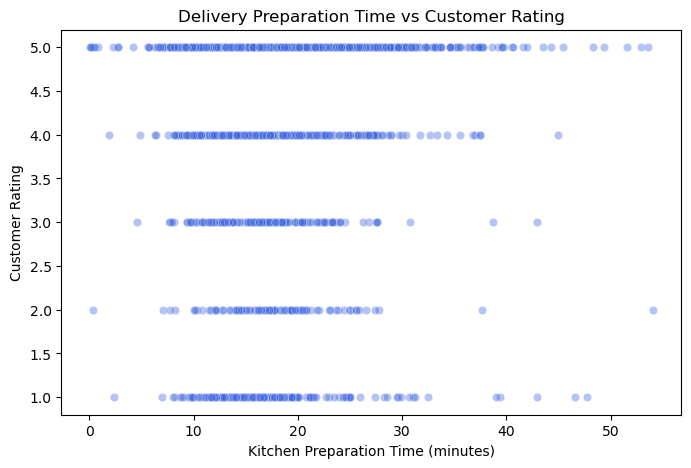

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=rating_data,
    x='kpt_duration',
    y='rating',
    alpha=0.4,
    color='royalblue'
)

plt.xlabel("Kitchen Preparation Time (minutes)")
plt.ylabel("Customer Rating")
plt.title("Delivery Preparation Time vs Customer Rating")

plt.show()

In [5]:
orders.to_csv("../data/processed/clean_orders.csv", index=False)

### 📊 Preparation Time Bucketing
Grouped preparation time into intervals (0–10, 10–20, etc.) to evaluate how increasing prep time affects average customer ratings.

In [6]:
orders['prep_time_bucket'] = pd.cut(
    orders['kpt_duration'],
    bins=[0,10,20,30,40,50,60],
    labels=['0-10','10-20','20-30','30-40','40-50','50-60']
)

prep_rating = (
    orders.groupby('prep_time_bucket')['rating']
    .mean()
    .reset_index()
)

prep_rating

C:\Users\lenovo\AppData\Local\Temp\ipykernel_16700\3963302143.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders.groupby('prep_time_bucket')['rating']


,prep_time_bucket,rating
0,0-10,4.268966
1,10-20,4.335753
2,20-30,4.420959
3,30-40,4.549451
4,40-50,3.928571
5,50-60,4.250000


In [7]:
prep_rating = prep_rating.sort_values('rating', ascending=False)
bucket_order = prep_rating['prep_time_bucket']

C:\Users\lenovo\AppData\Local\Temp\ipykernel_16700\3986571955.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


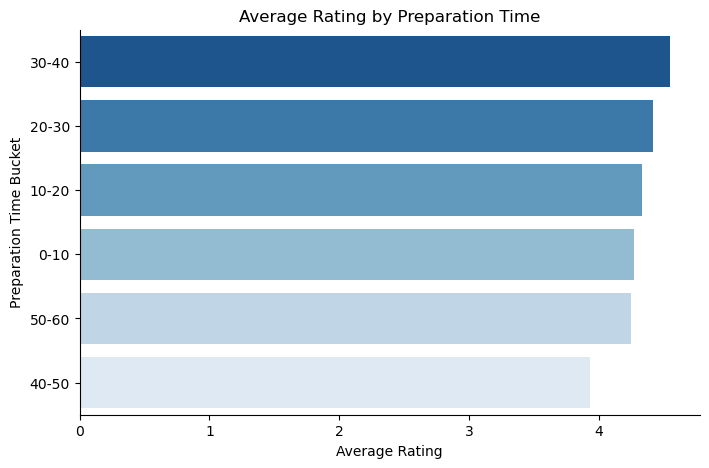

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=prep_rating,
    x='rating',
    y='prep_time_bucket',
    order=bucket_order,
    palette=sns.color_palette("Blues_r", len(prep_rating))
)

plt.xlabel("Average Rating")
plt.ylabel("Preparation Time Bucket")
plt.title("Average Rating by Preparation Time")

sns.despine()

plt.show()

### 🚴 Rider Waiting Time Impact
Segmented rider waiting time into buckets to analyze its effect on customer satisfaction and delivery experience.

In [9]:
orders['wait_time_bucket'] = pd.cut(
    orders['rider_wait_time'],
    bins=[0,5,10,15,20,30],
    labels=['0-5','5-10','10-15','15-20','20-30']
)

In [10]:
wait_rating = (
    orders.groupby('wait_time_bucket')['rating']
    .mean()
    .reset_index()
)

wait_rating = wait_rating.sort_values('rating', ascending=False)
wait_rating

C:\Users\lenovo\AppData\Local\Temp\ipykernel_16700\3077283592.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders.groupby('wait_time_bucket')['rating']


,wait_time_bucket,rating
4,20-30,4.545455
3,15-20,4.500000
1,5-10,4.372222
0,0-5,4.348955
2,10-15,4.292887


C:\Users\lenovo\AppData\Local\Temp\ipykernel_16700\3394403909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


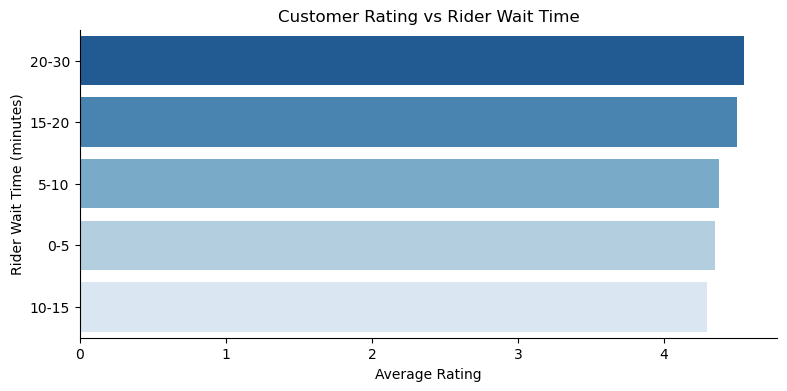

In [11]:
plt.figure(figsize=(9,4))

sns.barplot(
    data=wait_rating,
    x='rating',
    y='wait_time_bucket',
    order=wait_rating['wait_time_bucket'],
    palette=sns.color_palette("Blues_r", len(wait_rating))
)

plt.xlabel("Average Rating")
plt.ylabel("Rider Wait Time (minutes)")
plt.title("Customer Rating vs Rider Wait Time")

sns.despine()

plt.show()

In [12]:
orders.groupby('wait_time_bucket')['rating'].agg(['count','mean'])

C:\Users\lenovo\AppData\Local\Temp\ipykernel_16700\2526415948.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders.groupby('wait_time_bucket')['rating'].agg(['count','mean'])


,count,mean
wait_time_bucket,,
0-5,1579,4.348955
5-10,540,4.372222
10-15,239,4.292887
15-20,86,4.500000
20-30,33,4.545455


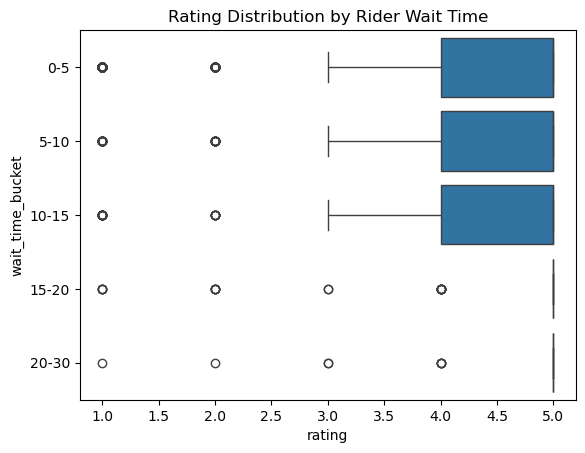

In [13]:
sns.boxplot(
    data=orders,
    x='rating',
    y='wait_time_bucket'
)
plt.title("Rating Distribution by Rider Wait Time")
plt.show()

### 🔗 Correlation Analysis
Evaluated relationships between key variables such as rating, preparation time, rider wait time, distance, and order value using correlation heatmaps.

In [14]:
orders[['rating','kpt_duration','rider_wait_time','distance_km','item_count','total']].corr()

,rating,kpt_duration,rider_wait_time,distance_km,item_count,total
rating,1.000000,0.017198,0.027857,0.027751,0.042224,0.059611
kpt_duration,0.017198,1.000000,0.472822,0.039619,0.359418,0.384006
rider_wait_time,0.027857,0.472822,1.000000,0.058212,0.119568,0.181320
distance_km,0.027751,0.039619,0.058212,1.000000,0.093023,0.116465
item_count,0.042224,0.359418,0.119568,0.093023,1.000000,0.638440
total,0.059611,0.384006,0.181320,0.116465,0.638440,1.000000


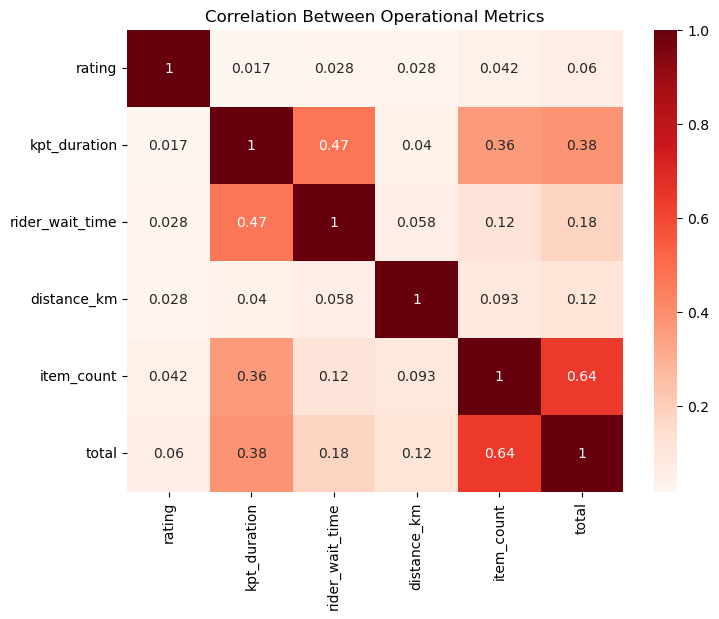

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    orders[['rating','kpt_duration','rider_wait_time','distance_km','item_count','total']].corr(),
    annot=True,
    cmap='Reds'
)

plt.title("Correlation Between Operational Metrics")

plt.show()

### 💡 Key Insights

- ⭐ **Customer ratings are largely independent of operational delays**
  → Correlation between rating and prep/wait time is extremely low (~0.02)

- ⏱️ **Longer preparation or wait time does not significantly reduce ratings**
  → Ratings remain stable (~4.2–4.5) across all time buckets

- 🔗 **Operational factors are interrelated**
  → Prep time and rider wait time show moderate correlation (0.47)

- 💰 **Order size strongly impacts revenue**
  → Item count and total order value show strong correlation (0.64)

- 📏 **Distance has minimal impact on performance or ratings**
  → Weak correlation across all variables

### 🧠 Business Recommendations

- ⭐ Focus on maintaining **consistent service quality**, as ratings are already stable  

- 🍽️ Higher prep times may indicate **premium or complex orders**, not inefficiency  
  → Avoid blindly optimizing for speed at the cost of quality  

- 💰 Focus on increasing **order size (upselling/combo offers)**  
  → Directly increases revenue  

- 📊 Do not rely only on ratings to measure performance  